# pRB/RB Ratio Analysis and AnnData Conversion Notebook

This notebook processes single-cell feature data, calculates the **pRB/RB ratio**, and incorporates it into an AnnData object for downstream analyses such as clustering, PHATE, and UMAP. The workflow includes the following steps:

---

### 1. Build Combined DataFrame
- Load per-well single-cell data from CSV files.
- Add metadata (treatment, dose, sample_ID, etc.).
- Concatenate all wells into a single `fullest_df`.

---

### 2. Calculate pRB/RB Ratio
- Compute the nuclear ratio:  
  \[{pRB/RB ratio} = {R0\_pRb\_nuc\_mean}/{R0\_Rb\_nuc\_mean}\]
- Store the ratio in the DataFrame for each cell.

---

### 3. Histogram & Threshold Selection
- Z-normalize the ratio distribution.  
- Plot histogram of ratios to visually inspect population structure.  
- Choose either:
  - **Single cutoff** → split into `pRB_low` and `pRB_high`.  
  - **Double cutoff** → split into `pRB_low`, `pRB_middle`, and `pRB_high`.  

---

### 4. Save Labels into DataFrame
- Add categorical labels (`pRB_low`, `pRB_high`, etc.) to the metadata.  
- Preserve both the raw ratio and its z-normalized version.

---

### 5. Create AnnData Object
- Separate **metadata** (goes to `.obs`) and **features** (goes to `.X`).  
- Z-normalize all features (including the ratio).  
- Save as `standard_adata.h5ad`.

---

### 6. Subsample with Sketch (Optional)
- Use `sketch` to generate a representative subsample of the data.  
- Save as `standard_adata_sub.h5ad` for faster exploratory analysis.

---

✅ Final products:  
- `standard_adata.h5ad` → full dataset with ratio + labels  
- `standard_adata_sub.h5ad` → subsampled dataset for visualization and quick analysis


In [49]:
import pickle
import os
import numpy as np
print("PYTHONPATH:", os.environ.get('PYTHONPATH'))
print("PATH:", os.environ.get('PATH'))
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import preprocessing
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import pandas as pd
import phate
import math
import random
import gc
import scprep
from datetime import datetime, time
from matplotlib.animation import ImageMagickWriter
import matplotlib.animation as animation
import zipfile
from urllib.request import urlopen
import scipy.stats as st
from scipy.stats import norm
from scipy.stats import gaussian_kde
from scipy.stats import kde
from scipy.stats import binned_statistic
from scipy.stats import f_oneway
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['pdf.fonttype'] = 42
print(sns.__version__)
from anndata import AnnData
import scanpy as sc
from delve import *
import anndata as ad
from sklearn.preprocessing import MinMaxScaler
from kh import sketch
from sklearn.cluster import KMeans
import umap
print(sc.__version__)
today = datetime.now().strftime("%m%d%Y-%H%M")

PYTHONPATH: None
PATH: c:\Users\Purvis_Jane\.conda\envs\python_3_7;C:\Users\Purvis_Jane\.conda\envs\python_3_7;C:\Users\Purvis_Jane\.conda\envs\python_3_7\Library\mingw-w64\bin;C:\Users\Purvis_Jane\.conda\envs\python_3_7\Library\usr\bin;C:\Users\Purvis_Jane\.conda\envs\python_3_7\Library\bin;C:\Users\Purvis_Jane\.conda\envs\python_3_7\Scripts;C:\Users\Purvis_Jane\.conda\envs\python_3_7\bin;C:\ProgramData\anaconda3\condabin;C:\ProgramData\anaconda3;C:\ProgramData\anaconda3\Library\mingw-w64\bin;C:\ProgramData\anaconda3\Library\usr\bin;C:\ProgramData\anaconda3\Library\bin;C:\ProgramData\anaconda3\Scripts;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\bin;C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.2\libnvvp;.;C:\WINDOWS\system32;C:\WINDOWS;C:\WINDOWS\System32\Wbem;C:\WINDOWS\System32\WindowsPowerShell\v1.0;C:\WINDOWS\System32\OpenSSH;C:\Program Files\NVIDIA Corporation\Nsight Compute 2020.3.0;C:\Program Files (x86)\NVIDIA Corporation\PhysX\Common;C:\Users\Purvis_Jane

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', 'src'))
from project_config import load_config

config    = load_config()
base_dir  = config['base_dir']
well_list = config['well_list']
full_dir  = os.path.join(base_dir, 'cell_data')

In [51]:
# Definition to Normalize the dataframe by z-score

def standardizeColumns(df): 
    df = df.copy()
    df.iloc[:,:] = df.iloc[:,:].apply(lambda x: (x-x.mean())/ x.std(), axis=0)
    return df

96 Well Plate Selector

Abemaciclib Treatment LPS 863 (D02-E08)

In [53]:
#Builds a dataframe for each well defined in well_list, then outputs the length of that list. The number output is how many cells
#were found in the well

fullest_df = pd.DataFrame()
for well in well_list:
    print(f'starting Well {well}')
    full_df = pd.read_csv(os.path.join(full_dir,f'cell_data_{well}_df.csv'), sep=',') 

   ### This part here is optional, you can add important metadata information at this step. Treatment and Sample ID are shown as examples
    if 'D' in well and ('02' in well):
        full_df['dose'] = '0'
        full_df['treatment'] = 'Control' 
        full_df['sample_ID'] = 1
       # full_df['Group'] = 1
    if 'D' in well and ('03' in well):
        full_df['dose'] = '10 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 2
       # full_df['Group'] = 1
    if 'D' in well and ('04' in well):
        full_df['dose'] = '25 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 3
       # full_df['Group'] = 1
    if 'D' in well and ('05' in well):
        full_df['dose'] = '50 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 4
       # full_df['Group'] = 1
    if 'D' in well and ('06' in well):
        full_df['dose'] = '100 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 5
        #full_df['Group'] = 1
    if 'D' in well and ('07' in well):
        full_df['dose'] = '250 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 6
        #full_df['Group'] = 1
    if 'D' in well and ('08' in well):
        full_df['dose'] = '500 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 7
        #full_df['Group'] = 1
    
    if 'E' in well and ('02' in well):
        full_df['dose'] = '0'
        full_df['treatment'] = 'Control' 
        full_df['sample_ID'] = 1
       # full_df['Group'] = 2
    if 'E' in well and ('03' in well):
        full_df['dose'] = '10 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 2
    if 'E' in well and ('04' in well):
        full_df['dose'] = '25 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 3
       # full_df['Group'] = 2
    if 'E' in well and ('05' in well):
        full_df['dose'] = '50 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 4
       # full_df['Group'] = 2
    if 'E' in well and ('06' in well):
        full_df['dose'] = '100 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 5
    if 'E' in well and ('07' in well):
        full_df['dose'] = '250 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 6
        #full_df['Group'] = 2
    if 'E' in well and ('08' in well):
        full_df['dose'] = '500 nM'
        full_df['treatment'] = 'Abema' 
        full_df['sample_ID'] = 7
        #full_df['Group'] = 2

    exec(f'well{well}_df = full_df.copy()')
    fullest_df = pd.concat([fullest_df, full_df], ignore_index = True)
    print(len(full_df))
    print(len(fullest_df))

### You may find that you need to force some of the columns added this way into specific data types. You can do that here.
# Convert sample_ID column to categorical data type
fullest_df['sample_ID'] = fullest_df['sample_ID'].astype('category')
fullest_df['dose'] = fullest_df['dose'].astype(str)
fullest_df['treatment'] = fullest_df['treatment'].astype(str)

starting Well D02
11392
11392
starting Well D03
10769
22161
starting Well D04
10081
32242
starting Well D05
9331
41573
starting Well D06
8448
50021
starting Well D07
8369
58390
starting Well D08
7806
66196
starting Well E02
11760
77956
starting Well E03
10847
88803
starting Well E04
9716
98519
starting Well E05
8882
107401
starting Well E06
8764
116165
starting Well E07
7783
123948
starting Well E08
7831
131779


In [8]:
fullest_df.columns

Index(['Unnamed: 0', 'label', 'nuc_area', 'centroid-0', 'centroid-1',
       'orientation', 'major_axis_length', 'minor_axis_length', 'bbox-0',
       'bbox-1',
       ...
       'R4_DNA_nuc_cyto_ratio', 'R4_pS6_nuc_cyto_ratio',
       'R4_S6_nuc_cyto_ratio', 'R5_DNA_nuc_cyto_ratio',
       'R5_Cdt1_nuc_cyto_ratio', 'R5_E2F1_nuc_cyto_ratio', 'well', 'dose',
       'treatment', 'sample_ID'],
      dtype='object', length=107)

In [ ]:
### Save the combined dataframe
fullest_df.to_csv(os.path.join(base_dir, 'fullest_df.csv'))


In [56]:
import pandas as pd

# Identify columns that contain any NaN values
columns_with_nan = fullest_df.columns[fullest_df.isnull().any()].tolist()

# Print the list of column headers with NaN values
print("Columns with NaN values:", columns_with_nan)

Columns with NaN values: []


In [57]:

# Definition to Normalize the dataframe by z-score

def standardizeColumns(df):
    df = df.copy()
    df.iloc[:,:] = df.iloc[:,:].apply(lambda x: (x-x.mean())/ x.std(), axis=0)
    return df

Adding in calculated features into fullest_df

In [58]:
fullest_df["pRb_Rb_ratio"] = fullest_df["R0_pRb_nuc_mean"] / fullest_df["R0_Rb_nuc_mean"]

In [59]:
fullest_df["pS6_S6_ratio"] = fullest_df["R4_pS6_nuc_mean"] / fullest_df["R4_S6_nuc_mean"]

In [60]:
fullest_df["total_pS6"] = (fullest_df["R4_pS6_nuc_mean"] + fullest_df["R4_pS6_ring_mean"])/2

In [61]:
fullest_df["total_DNA"] = fullest_df["R5_DNA_nuc_mean"] * fullest_df["nuc_area"]

In [62]:
fullest_df["total_cycB1"] = (fullest_df["R2_cycB1_nuc_mean"] + fullest_df["R2_cycB1_ring_mean"])/2

Generate histogram to determins pRB/RB ratio threshold

In [63]:
import numpy as np
from sklearn.preprocessing import StandardScaler

FEATURE = "pRb_Rb_ratio"

# Extract raw values from fullest_df
vals = np.asarray(fullest_df[FEATURE].values).ravel()

# Fit scaler on the FULL distribution of this feature
_scaler_full = StandardScaler().fit(vals.reshape(-1, 1))
vals_z = _scaler_full.transform(vals.reshape(-1, 1)).ravel()

print("Full-data z-scoring stats:")
print("  mean =", float(_scaler_full.mean_[0]))
print("  std  =", float(_scaler_full.scale_[0]))


Full-data z-scoring stats:
  mean = 0.7362221626400919
  std  = 0.27835160433073614


In [64]:
# You can adjust the number of bins here
N_BINS    = 70
FIGSIZE   = (16, 7)
BAR_ALPHA = 0.85
EDGE_LW   = 0.8

# Build histogram on Z-SCORED data (so cutoffs are in z-space)
counts, edges = np.histogram(vals_z, bins=N_BINS)
centers = 0.5 * (edges[:-1] + edges[1:])
widths  = edges[1:] - edges[:-1]


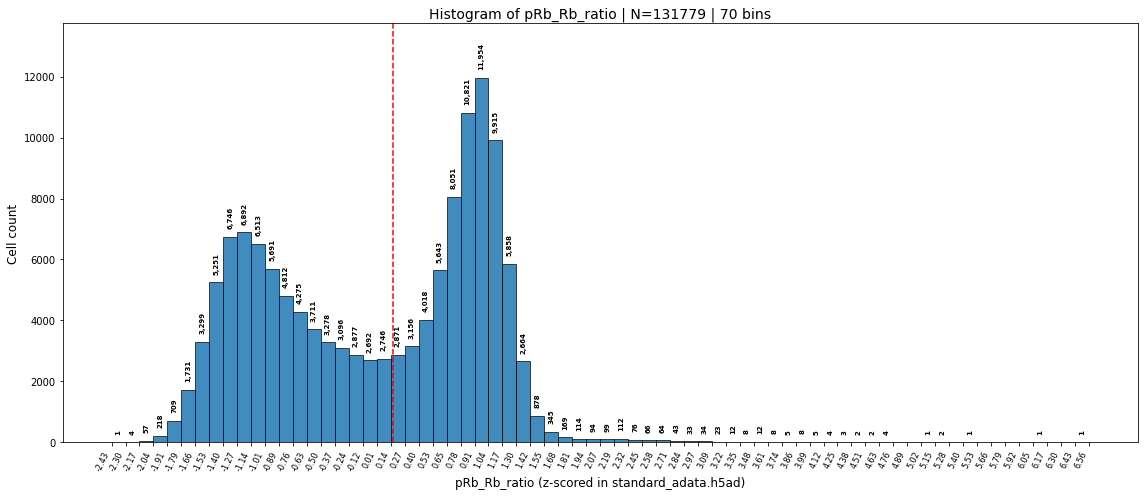

In [65]:
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.bar(centers, counts, width=widths, align="center",
       alpha=BAR_ALPHA, edgecolor="black", linewidth=EDGE_LW)

ymax = max(counts) * 1.15 if counts.size else 1.0
ax.set_ylim(0, ymax)

# Label counts above bars
for cx, cy in zip(centers, counts):
    if cy > 0:
        ax.text(cx, cy + (0.02 * ymax), f"{cy:,}",
                ha="center", va="bottom", fontsize=7, fontweight="bold", rotation=90)

# --- Tick marks at every bin edge, keep 0 as a visible tick ---
all_edges = edges
ax.set_xticks(all_edges)

# Format labels: show fewer decimals, emphasize 0
labels = []
for x in all_edges:
    labels.append("0" if np.isclose(x, 0, atol=1e-6) else f"{x:.2f}")
ax.set_xticklabels(labels, rotation=65, ha="right", fontsize=8)

# <<< Set your cutoff here in Z-SPACE after inspecting the histogram >>>
THRESHOLD_Z = 0.16   # e.g., -0.20 or 0.15, etc.

# Draw the vertical line at your z-cutoff
ax.axvline(THRESHOLD_Z, color="red", linestyle="--", linewidth=1.5)

ax.set_title(f"Histogram of {FEATURE} | N={vals.size} | {N_BINS} bins", fontsize=14)
ax.set_xlabel(f"{FEATURE} (z-scored in standard_adata.h5ad)", fontsize=12)
ax.set_ylabel("Cell count", fontsize=12)

plt.tight_layout()
plt.show()


In [66]:
import numpy as np
import anndata as ad
from pathlib import Path


ONE threshold cut off point to split cells into high or low pRB

In [24]:
# --- ONE threshold, label pRB_low / pRB_high on fullest_df ---

FEATURE = "pRb_Rb_ratio"

# You chose THRESHOLD_Z on your Z histogram above. Convert Z -> RAW once:
THRESHOLD_Z = 0.25 # <- whatever you picked on the z-hist plot
THRESHOLD_RAW = float(_scaler_full.inverse_transform([[THRESHOLD_Z]]).ravel()[0])

# Label on RAW values (from fullest_df)
vals_raw = fullest_df[FEATURE].astype(float).to_numpy()
labels   = np.where(vals_raw < THRESHOLD_RAW, "pRb_low", "pRb_high")

fullest_df["pRb_label"] = pd.Categorical(labels, categories=["pRb_low","pRb_high"])
print(fullest_df["pRb_label"].value_counts())
print("Cutoff used (RAW):", THRESHOLD_RAW, " | RAW min/max:", float(vals_raw.min()), float(vals_raw.max()))


pRb_low     67036
pRb_high    64743
Name: pRb_label, dtype: int64
Cutoff used (RAW): 0.8058100637227759  | RAW min/max: 0.060597337287384645 2.562185166913337


TWO threshold cut off points for splitting cells into high or low pRB

In [68]:
# --- TWO thresholds from Z histogram; map to RAW and label on RAW ---

FEATURE = "pRb_Rb_ratio"
THRESHOLD_LOW_Z  = -0.63   
THRESHOLD_HIGH_Z =  0.53   

THRESHOLD_LOW  = float(_scaler_full.inverse_transform([[THRESHOLD_LOW_Z]]).ravel()[0])
THRESHOLD_HIGH = float(_scaler_full.inverse_transform([[THRESHOLD_HIGH_Z]]).ravel()[0])
if THRESHOLD_LOW > THRESHOLD_HIGH:
    THRESHOLD_LOW, THRESHOLD_HIGH = THRESHOLD_HIGH, THRESHOLD_LOW

vals_raw = fullest_df[FEATURE].astype(float).to_numpy()
labels = np.full(vals_raw.shape[0], "pRb_middle", dtype=object)
labels[vals_raw < THRESHOLD_LOW]  = "pRb_low"
labels[vals_raw > THRESHOLD_HIGH] = "pRb_high"

fullest_df["pRb_label"] = pd.Categorical(labels, categories=["pRb_low","pRb_middle","pRb_high"])
print(fullest_df["pRb_label"].value_counts())
print("RAW cutoffs:", THRESHOLD_LOW, THRESHOLD_HIGH, " | RAW min/max:", float(vals_raw.min()), float(vals_raw.max()))

pRb_high      56969
pRb_low       46193
pRb_middle    28617
Name: pRb_label, dtype: int64
RAW cutoffs: 0.5608606519117281 0.883748512935382  | RAW min/max: 0.060597337287384645 2.562185166913337


Saving pRB_high pRB_low column and labels to fullest_df

In [69]:
# --- Saving pRB_high / pRB_low / pRB_middle labels into fullest_df ---
# note: "labels" must be defined by whichever threshold block you run above

# categorical label column
fullest_df["pRb_label"] = pd.Categorical(labels, categories=np.unique(labels))

# convenience booleans (only if you want them)
if "pRb_low" in labels:
    fullest_df["pRb_low"] = (fullest_df["pRb_label"] == "pRb_low")
if "pRb_middle" in labels:
    fullest_df["pRb_middle"] = (fullest_df["pRb_label"] == "pRb_middle")
if "pRb_high" in labels:
    fullest_df["pRb_high"] = (fullest_df["pRb_label"] == "pRb_high")

# quick counts
print(fullest_df["pRb_label"].value_counts())

pRb_high      56969
pRb_low       46193
pRb_middle    28617
Name: pRb_label, dtype: int64


Cleaning up fullest_df for conversion to AnnData object

In [70]:
print(fullest_df.columns.tolist())

['Unnamed: 0', 'label', 'nuc_area', 'centroid-0', 'centroid-1', 'orientation', 'major_axis_length', 'minor_axis_length', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'R0_DNA_nuc_mean', 'R0_pRb_nuc_mean', 'R0_Rb_nuc_mean', 'R0_CDK2_nuc_mean', 'R1_DNA_nuc_mean', 'R1_CDK4_nuc_mean', 'R1_p53_nuc_mean', 'R1_p21_nuc_mean', 'R2_DNA_nuc_mean', 'R2_cycD1_nuc_mean', 'R2_Mdm2_nuc_mean', 'R2_cycB1_nuc_mean', 'R3_DNA_nuc_mean', 'R3_Ki67_nuc_mean', 'R3_p16_nuc_mean', 'R3_cycA2_nuc_mean', 'R4_DNA_nuc_mean', 'R4_pS6_nuc_mean', 'R4_S6_nuc_mean', 'R5_DNA_nuc_mean', 'R5_Cdt1_nuc_mean', 'R5_E2F1_nuc_mean', 'nuc_mask', 'ring_area', 'R0_DNA_ring_mean', 'R0_pRb_ring_mean', 'R0_Rb_ring_mean', 'R0_CDK2_ring_mean', 'R1_DNA_ring_mean', 'R1_CDK4_ring_mean', 'R1_p53_ring_mean', 'R1_p21_ring_mean', 'R2_DNA_ring_mean', 'R2_cycD1_ring_mean', 'R2_Mdm2_ring_mean', 'R2_cycB1_ring_mean', 'R3_DNA_ring_mean', 'R3_Ki67_ring_mean', 'R3_p16_ring_mean', 'R3_cycA2_ring_mean', 'R4_DNA_ring_mean', 'R4_pS6_ring_mean', 'R4_S6_ring_mean'

In [77]:
import re

fullest_df = fullest_df.drop(columns=['Unnamed: 0', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'nuc_mask', 'ring_mask', 'ring_area'], errors='ignore')
columns_to_drop = ['Unnamed: 0', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'nuc_mask', 'ring_mask', 'ring_area']

# keep only last R#_DNA_nuc_mean ---
dna_cols = fullest_df.filter(regex=r"^R\d+_DNA_nuc_mean$").columns

if len(dna_cols) > 0:
    last_col = max(dna_cols, key=lambda c: int(c.split('_')[0][1:]))
    fullest_df = fullest_df.drop(columns=[c for c in dna_cols if c != last_col])

# --- METADATA (goes to .obs): include label, NOT the ratio ---
metadata_cols = ['label', 'well', 'sample_ID', 'dose', 'treatment', 'centroid-0', 'centroid-1', 'pRb_label']
metadata = fullest_df[metadata_cols].copy()

# --- FEATURES (go to .X): drop only metadata; KEEP pRb_rB_ratio so it is z-normalized ---
feature_df = fullest_df.drop(columns=metadata_cols, errors='ignore')

In [78]:
# --- FEATURES (go to .X): drop only metadata; KEEP pRb_Rb_ratio so it is z-normalized ---
feature_df = fullest_df.drop(columns=metadata_cols, errors='ignore')

# Keep numeric columns only (avoid strings like 'B02', '10 nM', etc.)
feature_df = feature_df.select_dtypes(include=['number']).copy()

# Z-normalize the features (this now includes pRb_Rb_ratio)
standard_df = standardizeColumns(feature_df)

# (Optional) if any columns still had non-numeric noise you coerced earlier:
# feature_df = feature_df.apply(pd.to_numeric, errors='coerce')
# standard_df = standardizeColumns(feature_df).dropna(axis=1, how='any')


In [79]:
import pandas as pd

# Remove columns that contain any NaN values
print("Shape before removing columns with NaN:", standard_df.shape)
standard_df = standard_df.dropna(axis=1, how='any')

# Print the shape of the DataFrame before and after removing columns with NaN
print("Shape after removing columns with NaN:", standard_df.shape)


Shape before removing columns with NaN: (131779, 92)
Shape after removing columns with NaN: (131779, 92)


Create standard_adata.h5ad

In [81]:
# Convert the pandas dataframe to an anndata object
standard_adata = ad.AnnData(standard_df)

# Add metadata back to the anndata object
standard_adata.obs = metadata.copy()
standard_adata.obs_names = [f'C_{i}' for i in standard_adata.obs_names]

# NEW: also expose the normalized ratio in .obs (pulled from the z-scored features)
standard_adata.obs["pRb_Rb_ratio"] = standard_df["pRb_Rb_ratio"].to_numpy()


#Save the entire adata file
adata_save_path = os.path.join(base_dir, 'standard_adata.h5ad')
standard_adata.write_h5ad(adata_save_path)


In [ ]:
#use this block if you want to load in a standard_adata.h5ad file to subsample wihtout creating a new one or overriding one.
#import anndata as ad

# Load the existing AnnData file (do NOT recreate or overwrite)
#adata_path = r"D:\Sam\4i_Liposarcoma_Data_YR2025\LPS_246_Abema_July_2025\standard_adata.h5ad"
#standard_adata = ad.read_h5ad(adata_path)

#print(f"Loaded standard AnnData: {standard_adata.shape}")


Loaded standard AnnData: (183389, 101)


In [82]:
###Sketching lets your subsample your data accurately. 
### This example groups for subsampling based on the sample_id metadata

idx, standard_adata_sub = sketch(standard_adata, num_subsamples = 2000, frequency_seed = 42, sample_set_key = 'sample_ID')
#Save the entire adata file
adata_save_path = os.path.join(base_dir, 'standard_adata.h5ad')
standard_adata_sub.write_h5ad(adata_save_path)


Subsequent notebooks will load in the saved adata file of your choice, either the full dataset of the subsampled dataset.
Additionally, you can produce any desired normalized or non-normalized adata file here. Z-score normalized is the provided example, but other methods can be used with minor modifications. i.e. min-max normalization using the provided code.

In [83]:
fullest_df.columns

Index(['label', 'nuc_area', 'centroid-0', 'centroid-1', 'orientation',
       'major_axis_length', 'minor_axis_length', 'R0_pRb_nuc_mean',
       'R0_Rb_nuc_mean', 'R0_CDK2_nuc_mean',
       ...
       'sample_ID', 'pRb_Rb_ratio', 'pS6_S6_ratio', 'total_pS6', 'total_DNA',
       'total_cycB1', 'pRb_label', 'pRb_low', 'pRb_middle', 'pRb_high'],
      dtype='object', length=103)

In [84]:
standard_adata_sub.obs

,label,well,sample_ID,dose,treatment,centroid-0,centroid-1,pRb_label,pRb_Rb_ratio
C_71190,5035,E02,1,0,Control,3463.257971,21.459903,pRb_high,0.992421
C_8195,8268,D02,1,0,Control,4969.148055,3256.791719,pRb_high,1.238538
C_4,27,D02,1,0,Control,7.849673,4499.107843,pRb_high,0.897346
C_8,31,D02,1,0,Control,6.074499,4428.962751,pRb_middle,0.427734
C_8201,8274,D02,1,0,Control,4970.514867,2141.921753,pRb_high,0.993160
...,...,...,...,...,...,...,...,...,...
C_124310,363,E08,7,500 nM,Abema,530.709646,5237.993110,pRb_middle,-0.075169
C_124315,368,E08,7,500 nM,Abema,537.048603,6214.686513,pRb_low,-1.553821
C_124324,377,E08,7,500 nM,Abema,550.273566,2360.133197,pRb_low,-1.210826
C_124327,380,E08,7,500 nM,Abema,555.936611,2666.857697,pRb_low,-0.987329
